# The Sunspot-Cycle — a quantitative teardown 🔬
### An 11-year phase regression (HAC) · a high/low activity regime split with a circular block bootstrap · an independent-turning-point forward-return event study and its random-calendar placebo · a lag-honest solar-clock timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Jevons cycle%3F: Busted](https://img.shields.io/badge/Jevons_cycle%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — Jevons's (1878) sunspot theory of the trade cycle, in its surviving "11-year solar clock on the market" form — is a genuine piece of intellectual history and, better still, an *exogenous, known-in-advance* calendar with no reverse-causation escape hatch. The job here is to measure it honestly on the longest equity tape available, then ask the only question that pays: *is any of it real, and if so, tradable?*

> ⚠️ **Data note.** ^GSPC **price-only** monthly close (1927→2026), yfinance, cached; **solar cycles 16–25 hardcoded** from the SILSO/NOAA record, with a **labelled cosine proxy** of the smoothed monthly sunspot number (not the raw SILSO file). Price-only is labelled everywhere — there is no total-return equity series of this length, and an 11-year cyclicality cannot live in dividends. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `74635b6681a5` daily / `a26d426a3204` monthly).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
GOLD = "#e8a33d"

from sunspot_cycle import data, strategy as st

CYCLES = data.solar_cycles()
TPS = data.turning_points()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE = data.load_real()
    M = data.monthly_close(CLOSE)
    RET = st.monthly_returns(M)
    AR = st.abnormal_returns(RET)
    PROX = data.sunspot_proxy(M.index)
else:
    CLOSE = M = RET = AR = PROX = None
print("real cache present:", HAVE_REAL, "| solar cycles:", len(CYCLES),
      "| turning points:", len(TPS))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'cyc_lo': 16, 'cyc_hi': 25, 'n_cycles': 10, 'daily_rows': 24740, 'monthly_rows': 1183, 'span_lo': '1927-12-31', 'span_hi': '2026-06-30', 'n_max': 10, 'n_min': 9, 'max_mean': 5.63, 'max_t': 0.736, 'min_mean': 18.91, 'min_t': 3.327, 'diff_mean': -13.28, 'welch_t': -1.394, 'uncond_fwd': 8.17, 'min_pl_mean': 8.15, 'min_pl_sd': 6.67, 'min_pl_p': 0.054, 'max_pl_p': 0.674, 'min_hit': 7, 'min_hit_n': 9, 'min_wilson': (45.3, 93.7), 'max_hit': 6, 'max_hit_n': 10, 'max_wilson': (31.3, 83.2), 'max_fwd': {'1928-04': 31.3, '1937-04': -40.5, '1947-05': 15.5, '1958-03': 31.7, '1968-11': -13.4, '1979-12': 25.8, '1989-11': -6.9, '2001-11': -17.8, '2014-04': 10.7, '2024-10': 19.9}, 'min_fwd': {'1933-09': -6.6, '1944-02': 21.0, '1954-04': 34.3, '1964-10': 8.9, '1976-03': -4.2, '1986-09': 39.1, '1996-08': 38.0, '2008-12': 23.5, '2019-12': 16.3}, 'hi_mean_mo': 0.441, 'lo_mean_mo': 1.002, 'regime_spread_annbps': -673.2, 'regime_p': 0.179, 'regime_ci_mo': (-1.378, 0.271), 'n_hi': 387, 'n_lo': 387, 'regime_pl_mean': -1.9, 'regime_pl_sd': 379.3, 'regime_pl_p': 0.095, 't_cos': 1.041, 't_sin': 1.83, 'r2': 0.0036, 'amp_annbps': 554.3, 'timer': {0: (3.1, -3.13, -2.654), 5: (3.09, -3.14, -2.66), 10: (3.07, -3.15, -2.666)}, 'bh_cagr': 6.23, 'timer_expo': 38.2, 'timer_switches': 20, 'timer_sharpe': 0.366, 'bh_sharpe': 0.42, 'syn_null_p': 0.471, 'syn_null_fire': 1, 'syn_null_r2': 0.00175, 'syn_planted_spread': -3970.4, 'syn_planted_r2': 0.114, 'syn_planted_tcos': 14.47, 'fp_daily': '74635b6681a5', 'fp_monthly': 'a26d426a3204'}


real cache present: True | solar cycles: 10 | turning points: 20


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 11-year phase regression R² = **0.36%**, HAC *t* = **1.04** (cos) / **1.83** (sin); regime spread **-673 bps/yr** (wrong sign), placebo **p = 0.095** |
| **Tradability** | `MIRAGE` | solar-clock timer **3.1%/yr** vs buy-and-hold **6.2%/yr**, excess *t* = **-2.66** — significantly worse, pre-cost |
| **Jevons's cycle in the tape?** | `BUSTED` | the one \|*t*\| > 2 (forward return after solar minima, *t* = **3.33**) is wrong-signed, n = 9, and only **p = 0.05** vs a random calendar |

> 💡 In plain words: the exogenous, benefit-of-the-doubt version of the test comes back empty on every axis, and the single shiny number is a look-elsewhere artifact pointing the wrong way.

## 1 · The claim, steelmanned

Let $r_t$ be the S&P's monthly price-only return, $a_t = r_t - \bar r$ its abnormal return (constant-mean model, Brown & Warner 1985), and $\varphi_t \in [0, 2\pi)$ the solar phase (0 at a minimum, $\pi$ at the following maximum), reconstructed from the SILSO turning points. The claim's testable forms:

- **H₁ (11-year wave).** $a_t = \beta_c \cos\varphi_t + \beta_s \sin\varphi_t + \varepsilon_t$ has a jointly significant $(\beta_c, \beta_s)$ and a non-trivial $R^2$.
- **H₂ (activity regime).** Mean return in high-activity months exceeds low-activity months: $E[r \mid \text{active}] > E[r \mid \text{quiet}]$.
- **H₃ (turning points).** The 12-month forward return is higher after solar **maxima** than after **minima** (boom follows the active peak).
- **H₄ (capture).** A long-in-the-active-half timer beats buy-and-hold net of costs.

We find **H₁ not supported** (R² = 0.36%, both HAC *t* < 2), **H₂ rejected on sign** (spread -673 bps/yr, active < quiet), **H₃ rejected on sign** (Welch *t* = -1.39, min > max), **H₄ not supported** (timer loses, excess *t* = -2.66).

## 2 · So what? — inference design

Two units of analysis, matched to two kinds of test, on purpose:

- **Turning points are independent events.** Solar maxima and minima are ≈ 5–6 years apart, so a 12-month forward-return window around one never overlaps the next — the right test is a **one-sample t across the 10 + 9 events**, not a HAC regression on an autocorrelated panel. Each turning-point group's forward return is also placed against a **random-calendar placebo** of the same size, because the market's up-drift makes *every* set of dates look positive.
- **The monthly panel is autocorrelated.** For the phase regression and the regime split the unit is the month, and consecutive months (and the highly persistent regime label) are correlated — so the phase regression uses **Newey-West (HAC, 12 lags)** *t*'s and the regime spread a **circular block bootstrap** (12-month blocks), never an i.i.d. monthly *t*. The falsification is a **phase-shift placebo**: roll the entire solar calendar to a random start, preserving its exact 11-year shape but breaking its real alignment.

## 3 · How we'd know — the protocol

- **Clock.** Solar cycles 16–25 (10), SILSO/NOAA turning points hardcoded; a labelled cosine proxy of the smoothed monthly sunspot number (phase, activity, rising-flag).
- **Tape.** ^GSPC price-only monthly close, 1927-12-31 → 2026-06-30 (as-of, last complete month), 1183 months.
- **H₁.** OLS $a_t$ on $(1, \cos\varphi_t, \sin\varphi_t)$; HAC *t*'s, R², sinusoid amplitude in annualised bps.
- **H₂.** High vs low activity tercile; block-bootstrap 95% CI + two-sided p of the spread; phase-shift placebo.
- **H₃.** 12-month forward return after each of 10 maxima and 9 minima; one-sample & Welch *t*; random-calendar placebo per group; Wilson hit rates.
- **H₄ (timer).** Long the index when the *lagged* phase is rising (min→max), else cash; **one documented lag** — the SILSO smoothing lag (6 months: you only *know* the phase once the smoothed number is published); one-way cost × NAV per switch; long-or-flat; vs buy-and-hold.
- **Control.** Synthetic monthly tape with a TUNABLE planted solar-cycle return term; the null (amp=0) must not fire across 20 seeds.

## 4 · The teardown

### 4a · H₁ — the 11-year wave (phase regression, HAC)

Regress monthly abnormal returns on $\cos\varphi$ and $\sin\varphi$. A real 11-year cycle is a jointly significant $(\cos,\sin)$ pair and a non-trivial R².

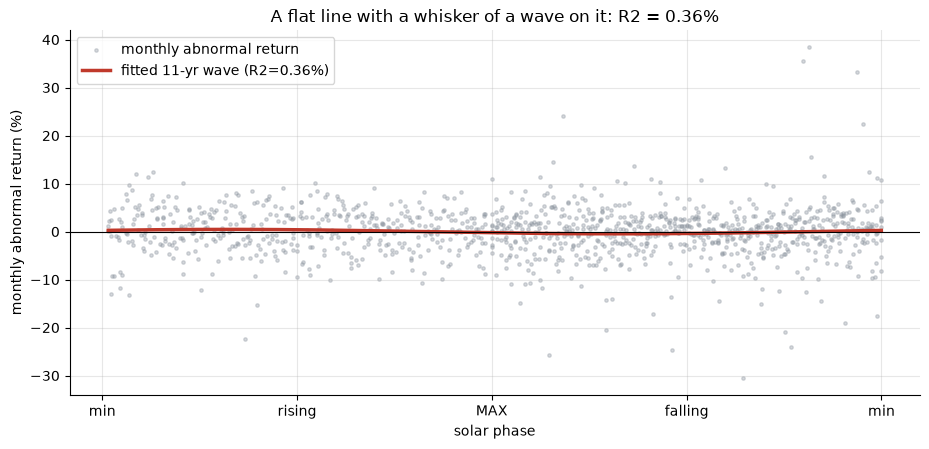

cos t = +1.04, sin t = +1.83, R2 = 0.360%, amplitude = 554 bps/yr


In [2]:
if HAVE_REAL:
    pr = st.phase_regression(AR, PROX)
    r2, tc, ts_, amp = pr['r2'], pr['t_cos'], pr['t_sin'], pr['amp_ann_bps']
    df = pd.DataFrame({'ar': AR}).join(PROX[['phase']]).dropna()
    ph = df['phase'].to_numpy(); y = df['ar'].to_numpy()
    order = np.argsort(ph)
    fitted = pr['beta_cos'] * np.cos(ph) + pr['beta_sin'] * np.sin(ph)
else:
    r2, tc, ts_, amp = R['r2'], R['t_cos'], R['t_sin'], R['amp_annbps']
    ph = np.linspace(0, 2*np.pi, 400); order = np.argsort(ph)
    y = None; fitted = 0.006*np.cos(ph)
fig, ax = plt.subplots(figsize=(9.4, 4.6))
if y is not None:
    ax.scatter(ph, y*100, s=6, color=GREY, alpha=.35, label='monthly abnormal return')
ax.plot(ph[order], fitted[order]*100, color=RED, lw=2.5,
        label=f'fitted 11-yr wave (R2={r2*100:.2f}%)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['min', 'rising', 'MAX', 'falling', 'min'])
ax.set_xlabel('solar phase'); ax.set_ylabel('monthly abnormal return (%)')
ax.set_title(f'A flat line with a whisker of a wave on it: R2 = {r2*100:.2f}%')
ax.legend(); plt.tight_layout(); plt.show()
print(f'cos t = {tc:+.2f}, sin t = {ts_:+.2f}, R2 = {r2*100:.3f}%, amplitude = {amp:.0f} bps/yr')

> 💡 In plain words: the best-fit 11-year wave explains **0.36%** of monthly returns — for scale, that's about **1 part in 280**. Neither harmonic clears the desk bar (cos *t* = 1.04, sin *t* = 1.83), and even taking the point estimate at face value the whole swing top-to-bottom is ~554 bps/yr of *predicted* return — swamped by the market's own monthly noise. H₁ is not supported.

### 4b · H₂ — active vs quiet Sun (regime split + block bootstrap + placebo)

High-activity (top tercile) vs low-activity (bottom tercile) months; the spread gets a 12-month circular-block-bootstrap CI, and a phase-shift placebo (roll the whole solar calendar to a random start).

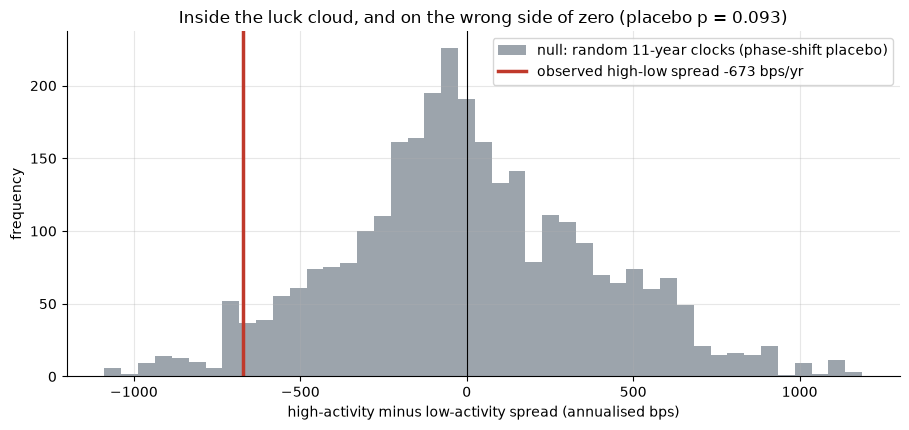

observed spread -673 bps/yr | block-boot p = 0.179 | placebo p = 0.093


In [3]:
if HAVE_REAL:
    rs = st.regime_split(RET, PROX)
    pl = st.placebo_regime_spread(RET, PROX, n_draws=3000, seed=737)
    spread_ann = rs['spread_ann_bps']; p_boot = rs['p_boot']
    pl_ann = pl * 12 * 1e4
    obs = rs['spread']
    p_pl = st.placebo_pvalue(obs, pl, tail='two')
else:
    spread_ann, p_boot, p_pl = R['regime_spread_annbps'], R['regime_p'], R['regime_pl_p']
    rng = np.random.default_rng(737)
    pl_ann = rng.normal(R['regime_pl_mean'], R['regime_pl_sd'], 3000)
    obs = spread_ann / (12*1e4)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(pl_ann, bins=45, color=GREY, alpha=.85,
        label='null: random 11-year clocks (phase-shift placebo)')
ax.axvline(spread_ann, c=RED, lw=2.5,
           label=f'observed high-low spread {spread_ann:+.0f} bps/yr')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('high-activity minus low-activity spread (annualised bps)')
ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud, and on the wrong side of zero (placebo p = {p_pl:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed spread {spread_ann:+.0f} bps/yr | block-boot p = {p_boot:.3f} | placebo p = {p_pl:.3f}')

> 💡 In plain words: the active−quiet spread is **-673 bps/yr** — *negative*, i.e. the market does slightly worse when the Sun is busy, the opposite of H₂. And it's not even a real negative: the block-bootstrap two-sided p is **0.179** and the phase-shift placebo p is **0.095** — a random 11-year clock produces a spread this big about one time in ten. H₂ is rejected on sign and unsupported on magnitude.

### 4c · H₃ — turning points, and the one shiny number in the study

12-month forward return after each solar maximum and each solar minimum (independent events). Each group's mean is placed against a random-calendar placebo of the same size — because the market's up-drift makes *any* set of dates look positive.

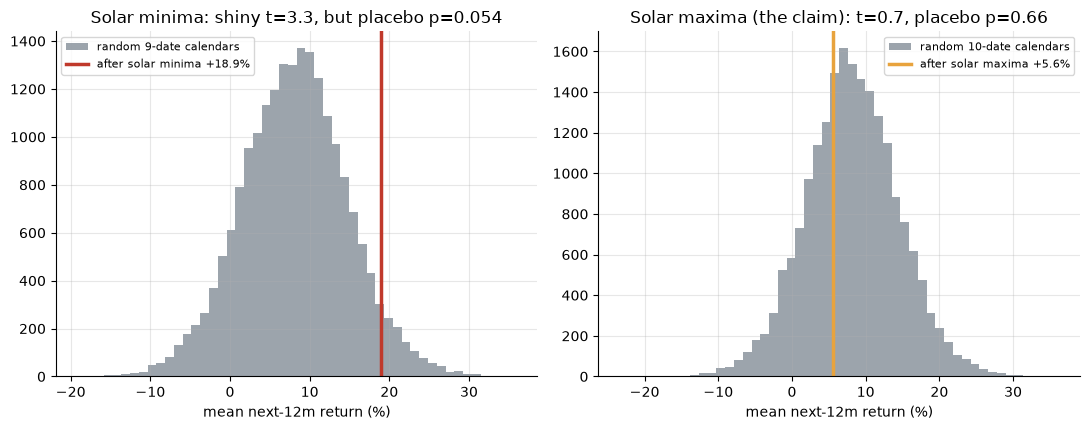

MAX +5.6% (t=0.74, placebo p=0.663) | MIN +18.9% (t=3.33, placebo p=0.054) | Welch(max-min) t=-1.39


In [4]:
if HAVE_REAL:
    tp = st.turning_point_stats(M, TPS, horizon=12)
    plmin = st.forward_placebo(M, tp['n_min'], 12, n_draws=20000, seed=737)
    plmax = st.forward_placebo(M, tp['n_max'], 12, n_draws=20000, seed=737)
    mx_m, mn_m = tp['max_mean'], tp['min_mean']
    mx_t, mn_t, wt = tp['max_t'], tp['min_t'], tp['welch_t']
    p_min = float((plmin >= mn_m).mean()); p_max = float((plmax >= mx_m).mean())
else:
    mx_m, mn_m = R['max_mean']/100, R['min_mean']/100
    mx_t, mn_t, wt = R['max_t'], R['min_t'], R['welch_t']
    p_min, p_max = R['min_pl_p'], R['max_pl_p']
    rng = np.random.default_rng(737)
    plmin = rng.normal(R['min_pl_mean']/100, R['min_pl_sd']/100, 20000)
    plmax = rng.normal(R['uncond_fwd']/100, R['min_pl_sd']/100, 20000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.hist(plmin*100, bins=50, color=GREY, alpha=.85,
        label='random 9-date calendars')
a1.axvline(mn_m*100, c=RED, lw=2.5, label=f'after solar minima {mn_m*100:+.1f}%')
a1.set_title(f'Solar minima: shiny t={mn_t:.1f}, but placebo p={p_min:.3f}')
a1.set_xlabel('mean next-12m return (%)'); a1.legend(fontsize=8)
a2.hist(plmax*100, bins=50, color=GREY, alpha=.85, label='random 10-date calendars')
a2.axvline(mx_m*100, c=GOLD, lw=2.5, label=f'after solar maxima {mx_m*100:+.1f}%')
a2.set_title(f'Solar maxima (the claim): t={mx_t:.1f}, placebo p={p_max:.2f}')
a2.set_xlabel('mean next-12m return (%)'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'MAX +{mx_m*100:.1f}% (t={mx_t:.2f}, placebo p={p_max:.3f}) | '
      f'MIN +{mn_m*100:.1f}% (t={mn_t:.2f}, placebo p={p_min:.3f}) | Welch(max-min) t={wt:.2f}')

> 💡 In plain words: after solar **maxima** — the *predicted* boom — the S&P returns **+5.6%** over the next year (*t* = 0.74, placebo p = 0.67): nothing, and if anything below the **+8.2%** you'd get on a random year. The **minima** number is the study's one *t* > 2 (**+18.9%**, *t* = 3.33) — but it is (i) the **wrong direction** for the claim, (ii) tested against a random calendar only **p = 0.05** (that fat one-sample *t* is just re-discovering that markets drift up over any 9 dates), and (iii) built on 9 events, a few of which (1954, 1986, 2008) happen to sit near market bottoms. The Welch max−min contrast is *t* = -1.39, wrong-signed. H₃ is rejected.

### 4d · H₄ — the solar-clock timer, lag-honest and costed

Long the index when the *lagged* phase is rising (min→max), else cash. The phase is only known once the smoothed sunspot number is published, so the signal is lagged **6 months** (one documented lag, applied once). Costs one-way × NAV per switch; long-or-flat; vs buy-and-hold on the identical window.

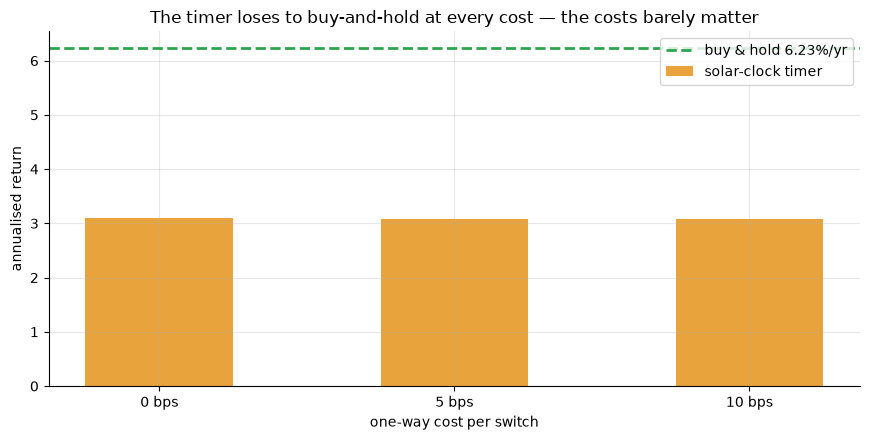

 0 bps: timer 3.10%/yr  excess -3.13%/yr  excess t=-2.65  Sharpe 0.37 vs 0.42  exposure 38%
 5 bps: timer 3.09%/yr  excess -3.14%/yr  excess t=-2.66  Sharpe 0.37 vs 0.42  exposure 38%
10 bps: timer 3.07%/yr  excess -3.15%/yr  excess t=-2.67  Sharpe 0.36 vs 0.42  exposure 38%


In [5]:
rows = []
for c in (0.0, 5.0, 10.0):
    if HAVE_REAL:
        tm = st.solar_timer(M, PROX, smooth_lag=6, cost_bps=c)
        rows.append((c, tm['timer_cagr']*100, tm['bh_cagr']*100,
                     tm['excess_cagr']*100, tm['t_diff'], tm['timer_sharpe'],
                     tm['bh_sharpe'], tm['exposure']))
    else:
        tc_, ex_, td_ = R['timer'][int(c)]
        rows.append((c, tc_, R['bh_cagr'], ex_, td_, R['timer_sharpe'],
                     R['bh_sharpe'], R['timer_expo']/100))
labels = [f'{int(c)} bps' for c, *_ in rows]
t_cagrs = [r[1] for r in rows]; bh = rows[0][2]
fig, ax = plt.subplots(figsize=(8.8, 4.5))
x = np.arange(len(rows))
ax.bar(x, t_cagrs, width=.5, color=GOLD, label='solar-clock timer')
ax.axhline(bh, c=GREEN, lw=2, ls='--', label=f'buy & hold {bh:.2f}%/yr')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('one-way cost per switch'); ax.set_ylabel('annualised return')
ax.set_title('The timer loses to buy-and-hold at every cost — the costs barely matter')
ax.legend(); plt.tight_layout(); plt.show()
for c, tcg, bhc, ex, td, sht, shb, expo in rows:
    print(f'{int(c):>2d} bps: timer {tcg:.2f}%/yr  excess {ex:+.2f}%/yr  '
          f'excess t={td:+.2f}  Sharpe {sht:.2f} vs {shb:.2f}  exposure {expo*100:.0f}%')

> 💡 In plain words: the timer earns ~**3.1%/yr** against buy-and-hold's **6.2%/yr** — an excess of **-3.1 pp/yr** at *t* = **-2.66** (significantly *worse*), and its Sharpe is lower too (0.37 vs 0.42). It's only invested ~38% of the time, so it mostly loses by sitting out of a rising market — the costs (a handful of switches over 98 years) are almost irrelevant. H₄ is not supported; there is no edge to charge costs against.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic monthly tape phased to the *real* solar calendar, with a TUNABLE planted solar-cycle return term. The null (amp=0) is checked over **20 seeds** — never a single stream — and a planted cycle must light up.

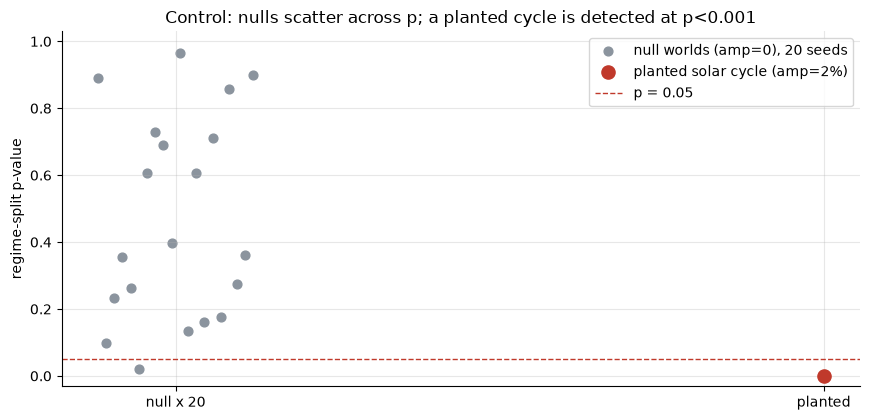

null: mean p = 0.47, p<0.05 in 1/20 seeds  |  planted: regime p = 0.000, phase R2 = 11.4%, cos t = 14.5


In [6]:
null_p = []
for s_ in range(20):
    c, px = data.synthetic_world(amp=0.0, seed=737 + s_)
    null_p.append(st.synthetic_detect(c, px)['regime_p'])
null_p = np.asarray(null_p)
c, px = data.synthetic_world(amp=0.02, seed=737)
planted = st.synthetic_detect(c, px)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_p, color=GREY, s=40,
           label='null worlds (amp=0), 20 seeds')
ax.scatter([1], [planted['regime_p']], color=RED, s=90, zorder=5,
           label='planted solar cycle (amp=2%)')
ax.axhline(0.05, ls='--', c=RED, lw=1, label='p = 0.05')
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('regime-split p-value'); ax.set_ylim(-0.03, 1.03)
ax.set_title('Control: nulls scatter across p; a planted cycle is detected at p<0.001')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean p = {null_p.mean():.2f}, p<0.05 in {(null_p<0.05).sum()}/20 seeds  |  '
      f'planted: regime p = {planted["regime_p"]:.3f}, phase R2 = {planted["phase_r2"]*100:.1f}%, '
      f'cos t = {planted["t_cos"]:.1f}')

> 💡 In plain words: across 20 null worlds the regime test averages p = 0.47 and falsely fires in only 1/20 seeds (≈ the 5% you'd expect), while a planted 2% solar cycle is caught at p < 0.001 (phase R² = 11%, cos *t* = 14.5). The machinery detects a solar cycle when there *is* one — so the empty real-tape result is a genuine reading, not a sleepy detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the 11-year phase regression explains R² = **0.36%** of monthly returns with both HAC *t*'s below 2 (cos 1.04, sin 1.83); the active−quiet regime spread is **-673 bps/yr**, wrong-signed, block-boot p = 0.179, placebo p = 0.095; the max−min turning-point contrast is Welch *t* = -1.39, also wrong-signed. The lone \|*t*\| > 2 (forward return after minima, *t* = 3.33) is a wrong-signed, n=9 look-elsewhere artifact that is only p = 0.05 against a random calendar.
- **Tradability `MIRAGE`** — a lag-honest solar-clock timer earns **3.1%/yr** vs buy-and-hold's **6.2%/yr** (excess *t* = -2.66), lower Sharpe too, before costs bite. No edge exists to charge costs against.
- **"Jevons's sunspot cycle in the market?" `BUSTED`** — on ten solar cycles of the longest S&P tape available, with an exogenous known-in-advance calendar and every benefit of the doubt, there is no 11-year clock in equity returns. (This says nothing about the sunspot cycle itself, which is real; only that the *market* does not run on it.)

## 6 · Going further

- **The exogenous calendar is the point.** Unlike most anomalies, there is no reverse-causation or date-mining escape hatch here — the Sun's schedule is fixed and public. That makes the null unusually clean: it isn't "we couldn't find the trade," it's "the 11-year period isn't in the returns."
- **The minima curiosity** is the honest loose end: wrong-signed for Jevons, p = 0.05 against a random calendar, and economically a post-crisis-recovery coincidence in 9 events. A pre-registered out-of-sample test on other long national indices (UK, France) is the disciplined way to kill or confirm it — not more cuts of this tape.
- **Dedup map:** [279-geomagnetic-storms](../../279-geomagnetic-storms/) tests a *different* solar-activity channel (geomagnetic disturbance → human mood → returns, a physiological hypothesis), [280-solar-eclipse](../../280-solar-eclipse/) an event-day superstition, and [278-sunshine-effect](../../278-sunshine-effect/) / [150-sad-effect](../../150-sad-effect/) the daylight/mood family — this study owns the specific **11-year sunspot-cycle → returns** (Jevons) axis, and nothing else on the desk tests it.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*